# Detecção de Fraude em Transações Bancárias — Global Trust Bank

**Projeto Final — EBAC "Profissão: Cientista de Dados" (Módulo 43)**

## Contexto de negócio

O time de risco do **Global Trust Bank** processou 284.807 transações de
cartão de crédito em um período de 2 dias (setembro/2023). Dessas, **492
foram identificadas como fraude (0,172%)**. O gestor de risco pediu um
modelo capaz de identificar fraudes o mais rápido possível, para minimizar
prejuízo financeiro e preservar a experiência de clientes legítimos.

## Definição do problema

| Item | Definição |
|---|---|
| **Problema de negócio** | Identificar transações fraudulentas em tempo hábil, minimizando prejuízo financeiro e fricção com clientes legítimos. |
| **Tipo de tarefa de ML** | Classificação binária supervisionada. |
| **Variável-alvo** | `Class` (0 = legítima, 1 = fraude). |
| **Restrição crítica** | Dataset extremamente desbalanceado (1 fraude para cada ~578 transações legítimas) — acurácia é métrica enganosa aqui. |
| **Custo assimétrico do negócio** | Falso Negativo (fraude não detectada) é muito mais caro que Falso Positivo (cliente legítimo com transação sinalizada). |

As colunas `V1` a `V28` são componentes principais (PCA) de variáveis
originais sigilosas (dado sensível bancário) — isso preserva a privacidade
dos clientes, mas **elimina a possibilidade de interpretação de negócio
direta** dessas variáveis (uma armadilha estrutural desta base que
precisa ser reconhecida explicitamente).


In [1]:
import sys
sys.path.append("../src")

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from data_prep import load_raw_data, clean_data
from features import add_engineered_features

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
ROOT = Path("..")


## 1. Entendimento do problema e dos dados

In [2]:
df_raw = load_raw_data(ROOT / "data" / "raw" / "creditcard.csv")
print(f"Shape bruto: {df_raw.shape}")
df_raw.info()


Shape bruto: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [3]:
# Estatística descritiva geral
df_raw.describe().T[["count", "mean", "std", "min", "50%", "max"]]


,count,mean,std,min,50%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,84692.000000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,0.018109,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,0.065486,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,0.179846,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.019847,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.054336,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.274187,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,0.040103,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,0.022358,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.051429,15.594995


In [4]:
print("Valores nulos por coluna (soma total):", df_raw.isnull().sum().sum())
print("Linhas duplicadas exatas:", df_raw.duplicated().sum())


Valores nulos por coluna (soma total): 0


Linhas duplicadas exatas: 1081


**Técnica de EDA #1 — Sanidade dos dados.** A base não tem valores nulos,
mas tem **1.081 linhas duplicadas** — essa é a primeira armadilha
estrutural: se não removermos as duplicatas antes do split treino/teste,
corremos o risco de a mesma transação (ou uma quase-idêntica) aparecer
nos dois conjuntos, inflando artificialmente a performance do modelo
(vazamento de dados).


In [5]:
df = clean_data(df_raw)  # remove duplicatas, valida ausência de nulos
df = add_engineered_features(df)  # Hour, Amount_log
df.head()


Duplicatas removidas: 1081 (284807 -> 283726)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0,4.262539


## 2. Análise Exploratória de Dados (Python)

**Técnica de EDA #2 — Distribuição da variável-alvo.**


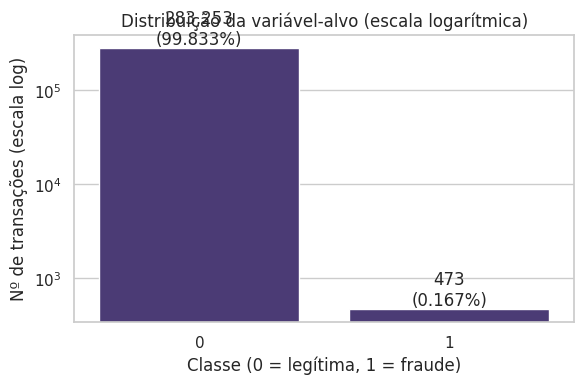

In [6]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Classe (0 = legítima, 1 = fraude)")
ax.set_ylabel("Nº de transações (escala log)")
ax.set_title("Distribuição da variável-alvo (escala logarítmica)")
for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, count, f"{count:,}\n({pct:.3f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "01_distribuicao_classe.png")
plt.show()


**Insight:** o desbalanceamento é extremo (~578:1). Um modelo ingênuo que
sempre prevê "não fraude" atinge 99,83% de acurácia sem identificar
nenhuma fraude — por isso a acurácia não pode ser a métrica de decisão
deste projeto.


**Técnica de EDA #3 — Distribuição de `Amount` e `Time` por classe.**


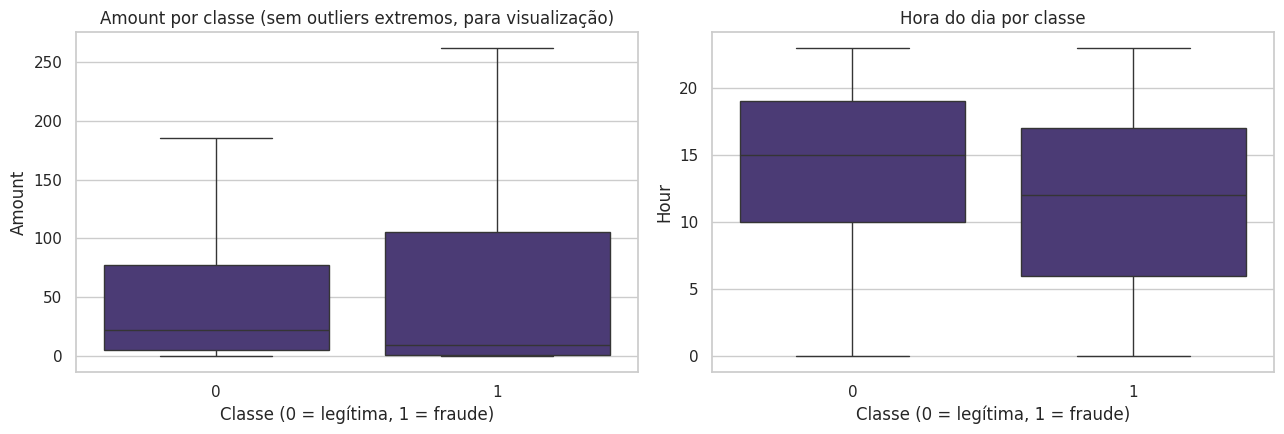

,mean,median,std,min,max
Class,,,,,
0,88.41,22.00,250.38,0.0,25691.16
1,123.87,9.82,260.21,0.0,2125.87


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], showfliers=False)
axes[0].set_title("Amount por classe (sem outliers extremos, para visualização)")
axes[0].set_xlabel("Classe (0 = legítima, 1 = fraude)")

sns.boxplot(data=df, x="Class", y="Hour", ax=axes[1])
axes[1].set_title("Hora do dia por classe")
axes[1].set_xlabel("Classe (0 = legítima, 1 = fraude)")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "02_amount_hour_por_classe.png")
plt.show()

df.groupby("Class")["Amount"].agg(["mean", "median", "std", "min", "max"]).round(2)


**Insight:** a **mediana** do valor das fraudes é *menor* que a das
transações legítimas, mas a **média** é maior — indicando que a
distribuição de fraudes tem uma cauda longa (alguns golpes de valor bem
alto puxam a média para cima). Isso sugere que fraudadores tendem a fazer
muitas transações de baixo valor (testando limites/validando cartões) e
ocasionalmente uma transação de valor elevado.


**Técnica de EDA #4 — Separabilidade das componentes PCA por classe.**


In [8]:
# Seleciona as variáveis mais correlacionadas (em módulo) com a classe
corr_with_class = df[[f"V{i}" for i in range(1, 29)] + ["Class"]].corr()["Class"].drop("Class")
top_vars = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 componentes PCA mais correlacionadas (em módulo) com a fraude:")
print(corr_with_class[top_vars].sort_values())


Top 6 componentes PCA mais correlacionadas (em módulo) com a fraude:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
Name: Class, dtype: float64


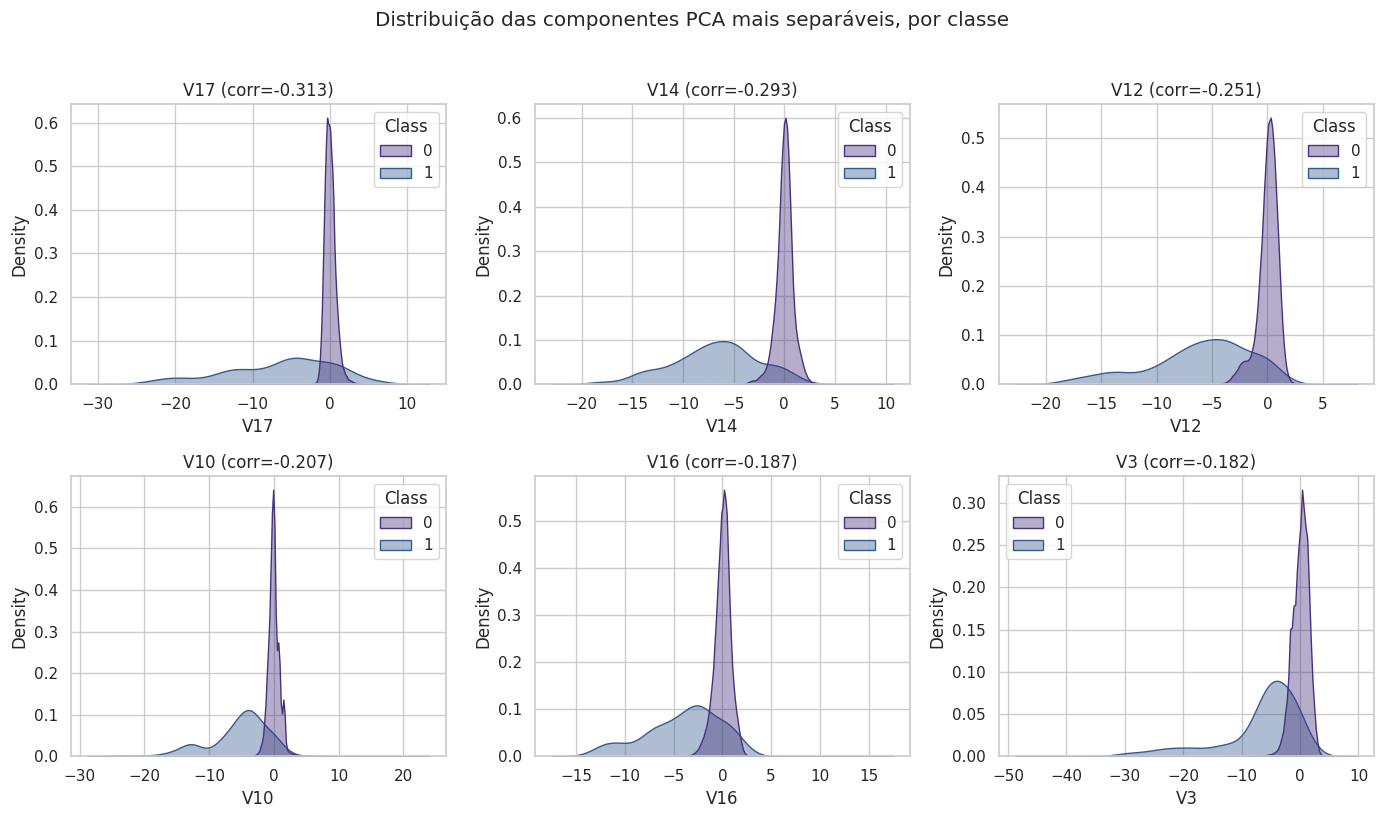

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, var in zip(axes.flat, top_vars):
    sns.kdeplot(data=df, x=var, hue="Class", common_norm=False, ax=ax, fill=True, alpha=0.4)
    ax.set_title(f"{var} (corr={corr_with_class[var]:.3f})")
plt.suptitle("Distribuição das componentes PCA mais separáveis, por classe", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "03_separabilidade_pca.png", bbox_inches="tight")
plt.show()


**Insight:** apesar de serem componentes PCA anônimas (sem significado de
negócio direto), algumas delas mostram separação visual clara entre
classes — é um sinal forte de que um modelo supervisionado consegue
aprender um limite de decisão eficaz mesmo sem interpretabilidade direta
das features.


**Técnica de EDA #5 — Matriz de correlação.**


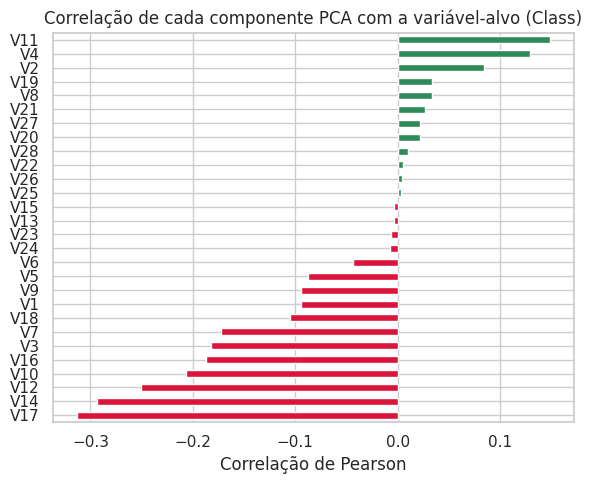

In [10]:
plt.figure(figsize=(6, 5))
corr_with_class.sort_values().plot(kind="barh", color=[
    "crimson" if v < 0 else "seagreen" for v in corr_with_class.sort_values()
])
plt.title("Correlação de cada componente PCA com a variável-alvo (Class)")
plt.xlabel("Correlação de Pearson")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "04_correlacao_com_class.png")
plt.show()


**Técnica de EDA #6 — Padrão temporal (engenharia de `Hour`).**


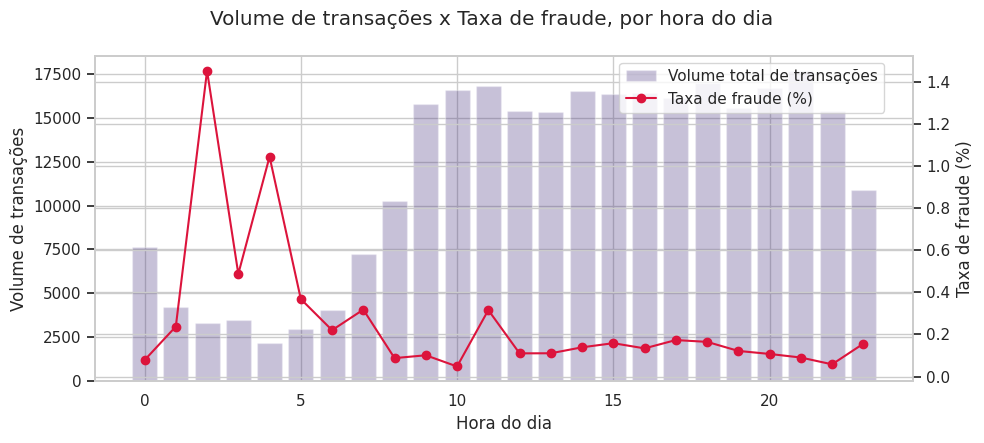

,sum,count,taxa_fraude_pct
Hour,,,
2,48,3308,1.4510
4,23,2204,1.0436
3,17,3487,0.4875
5,11,2988,0.3681
7,23,7233,0.3180


In [11]:
hourly = df.groupby("Hour")["Class"].agg(["sum", "count"])
hourly["taxa_fraude_pct"] = (hourly["sum"] / hourly["count"]) * 100

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(hourly.index, hourly["count"], alpha=0.3, label="Volume total de transações")
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Volume de transações")
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["taxa_fraude_pct"], color="crimson", marker="o", label="Taxa de fraude (%)")
ax2.set_ylabel("Taxa de fraude (%)")
fig.suptitle("Volume de transações x Taxa de fraude, por hora do dia")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "05_padrao_horario.png")
plt.show()

hourly.round(4).sort_values("taxa_fraude_pct", ascending=False).head(5)


**Insight:** a taxa de fraude é mais alta durante a madrugada (pico às 2h
e 4h), justamente quando o volume total de transações legítimas é baixo —
proporcionalmente, fraudadores parecem preferir horários de menor
monitoramento/atividade.


**Técnica de EDA #7 — Testes estatísticos de hipótese.**

Como as variáveis não seguem distribuição normal (PCA + cauda longa em
`Amount`), usamos o teste não-paramétrico de **Mann-Whitney U** para
comparar as distribuições entre classes de forma estatisticamente
rigorosa (não apenas visual).


In [12]:
vars_to_test = ["Amount", "Amount_log"] + top_vars
test_results = []
for var in vars_to_test:
    legit = df.loc[df["Class"] == 0, var]
    fraud = df.loc[df["Class"] == 1, var]
    stat, p_value = stats.mannwhitneyu(legit, fraud, alternative="two-sided")
    test_results.append({
        "variavel": var,
        "estatistica_U": stat,
        "p_valor": p_value,
        "significativo_5pct": p_value < 0.05,
    })

test_df = pd.DataFrame(test_results)
test_df


,variavel,estatistica_U,p_valor,significativo_5pct
0,Amount,74461539.5,2.686090e-05,True
1,Amount_log,74461539.5,2.686090e-05,True
2,V17,107246213.0,2.854261e-113,True
3,V14,126896444.0,2.304859e-248,True
4,V12,125197232.0,1.358344e-234,True
5,V10,121998541.0,9.598036e-210,True
6,V16,112734405.0,1.110506e-145,True
7,V3,121738405.0,8.738656e-208,True


**Insight estatístico:** todas as variáveis testadas apresentam diferença
estatisticamente significativa (p < 0,05) entre transações legítimas e
fraudulentas pelo teste de Mann-Whitney U — reforçando, com rigor
estatístico (e não apenas inspeção visual de gráficos), que essas
variáveis carregam sinal real para separar as classes.


## 3. Consolidação dos insights da fase exploratória

1. **Desbalanceamento extremo** (0,172% de fraude) — acurácia não é métrica válida; o projeto precisa ser guiado por recall/PR-AUC e pela análise de custo de negócio.
2. **1.081 duplicatas exatas** identificadas e removidas antes do split, para evitar vazamento de dados.
3. **Fraudes têm mediana de valor menor, mas média maior** que transações legítimas — sugere padrão misto de "testes de cartão" (valores baixos) e golpes pontuais de alto valor.
4. **Componentes PCA como V14, V4, V10, V12** mostram separação visual e estatisticamente significativa entre classes, mesmo sem interpretação de negócio direta (dado sigiloso).
5. **Padrão horário**: taxa de fraude é proporcionalmente mais alta na madrugada, quando o volume de transações legítimas cai — possível sinal de comportamento evasivo do fraudador.
6. **Sem valores nulos**, o que simplifica a etapa de tratamento de ausentes, mas não elimina a necessidade de tratar a tipagem e a escala de `Amount`/`Time`.
7. **Todas as diferenças entre classes são estatisticamente significativas** (Mann-Whitney U, p < 0,05) nas variáveis mais correlacionadas — validação estatística além do gráfico.


## 4. Camada SQL — validação de negócio direto na base

Como complemento ao EDA em Python, replicamos parte da análise
diretamente em **SQL** sobre um banco SQLite (`sql/load_data.py` +
`sql/eda_queries.sql`), simulando o cenário real de um analista
consultando a base de transações do banco.


In [13]:
conn = sqlite3.connect(ROOT / "data" / "processed" / "fraud_detection.db")

query_prejuizo = '''
SELECT
    ROUND(SUM(CASE WHEN Class = 1 THEN Amount ELSE 0 END), 2) AS valor_total_fraudes,
    ROUND(SUM(Amount), 2) AS valor_total_transacionado,
    ROUND(100.0 * SUM(CASE WHEN Class = 1 THEN Amount ELSE 0 END) / SUM(Amount), 4)
        AS percentual_prejuizo_sobre_volume
FROM transactions;
'''
pd.read_sql_query(query_prejuizo, conn)


,valor_total_fraudes,valor_total_transacionado,percentual_prejuizo_sobre_volume
0,60127.97,25162590.01,0.239


In [14]:
query_faixas = '''
SELECT
    CASE
        WHEN Amount = 0 THEN '00 - Zero'
        WHEN Amount <= 10 THEN '01 - Ate 10'
        WHEN Amount <= 50 THEN '02 - 10 a 50'
        WHEN Amount <= 100 THEN '03 - 50 a 100'
        WHEN Amount <= 500 THEN '04 - 100 a 500'
        WHEN Amount <= 2000 THEN '05 - 500 a 2000'
        ELSE '06 - Acima de 2000'
    END AS faixa_valor,
    COUNT(*) AS total_transacoes,
    SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) AS fraudes,
    ROUND(100.0 * SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END) / COUNT(*), 4) AS taxa_fraude_pct
FROM transactions
GROUP BY faixa_valor
ORDER BY faixa_valor;
'''
pd.read_sql_query(query_faixas, conn)


,faixa_valor,total_transacoes,fraudes,taxa_fraude_pct
0,00 - Zero,1825,27,1.4795
1,01 - Ate 10,98439,222,0.2255
2,02 - 10 a 50,90781,57,0.0628
3,03 - 50 a 100,37254,56,0.1503
4,04 - 100 a 500,47366,95,0.2006
5,05 - 500 a 2000,8466,34,0.4016
6,06 - Acima de 2000,676,1,0.1479


**Insight (SQL):** o prejuízo direto das fraudes representa apenas
~0,24% do volume financeiro total transacionado no período — um número
que sozinho parece pequeno, mas em escala (bilhões de transações/ano em
um banco real) e considerando o dano reputacional, justifica plenamente
o investimento em um modelo de detecção. Além disso, transações de valor
zero (frequentemente usadas para *validar* se um cartão roubado está
ativo) têm a **maior taxa de fraude entre todas as faixas (1,48%)** — um
padrão clássico de fraude que vale citar ao stakeholder.


In [15]:
conn.close()


## 5. Preparação dos dados para modelagem (sem vazamento)

A ordem de operações é crítica para não vazar informação do teste para o
treino:

1. Engenharia de variáveis (`Hour`, `Amount_log`) — não aprende parâmetros dos dados, pode ser feita antes do split.
2. **Split treino/teste estratificado** (70/30), preservando a proporção de fraudes em ambos os conjuntos.
3. **Somente depois do split**: fit do `StandardScaler` no treino, aplicado (transform) no teste.
4. Reamostragem (SMOTE) e ajuste de hiperparâmetros ocorrem **apenas no conjunto de treino**.

Essa lógica está implementada em `src/train_model.py`, que roda o
pipeline completo de treino/avaliação de forma reprodutível (fixando
`random_state=42`) e persiste os artefatos em `models/` e as métricas em
`outputs/metrics.json`, consumidos nas seções seguintes deste notebook.


In [16]:
from sklearn.model_selection import train_test_split
from features import get_feature_matrix

X, y = get_feature_matrix(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f"Treino: {X_train.shape} | Fraudes: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Teste:  {X_test.shape} | Fraudes: {y_test.sum()} ({y_test.mean()*100:.4f}%)")


Treino: (198608, 30) | Fraudes: 331 (0.1667%)
Teste:  (85118, 30) | Fraudes: 142 (0.1668%)


## 6. Modelagem — comparação de múltiplos modelos

Modelos comparados no pipeline (`src/train_model.py`):

1. **DummyClassifier** (baseline "sempre legítima") — prova que acurácia é enganosa.
2. **Regressão Logística** (`class_weight='balanced'`) — baseline interpretável.
3. **Random Forest** (`class_weight='balanced'`).
4. **XGBoost** (`scale_pos_weight`) — modelo principal, com e sem threshold otimizado por F2.
5. **XGBoost + SMOTE** — comparação de estratégia de reamostragem.
6. **Isolation Forest** (não-supervisionado) — abordagem bônus/inovadora, útil como detector complementar de anomalias sem depender do rótulo `Class`.

Validação cruzada estratificada (5 folds) foi aplicada ao modelo
principal para garantir estabilidade da métrica PR-AUC.


In [17]:
with open(ROOT / "outputs" / "metrics.json", encoding="utf-8") as f:
    results = json.load(f)

metrics_df = pd.DataFrame(results["resultados_modelos"])
metrics_df = metrics_df[[
    "model", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc",
    "false_negative", "false_positive", "custo_financeiro_simulado_R$"
]]
metrics_df


,model,precision,recall,f1,f2,roc_auc,pr_auc,false_negative,false_positive,custo_financeiro_simulado_R$
0,Dummy (baseline),0.0000,0.0000,0.0000,0.0000,0.5000,0.0017,142,0,71000.0
1,Regressão Logística,0.0509,0.8873,0.0963,0.2070,0.9629,0.6911,16,2349,19745.0
2,Random Forest,0.8833,0.7465,0.8092,0.7703,0.9678,0.8082,36,14,18070.0
3,XGBoost (scale_pos_weight),0.9000,0.7606,0.8244,0.7849,0.9661,0.8154,34,12,17060.0
4,XGBoost (threshold otimizado p/ F2),0.8409,0.7817,0.8102,0.7929,0.9661,0.8154,31,21,15605.0
5,XGBoost + SMOTE,0.7826,0.7606,0.7714,0.7649,0.9677,0.7937,34,30,17150.0
6,Isolation Forest (não-supervisionado),0.2340,0.2324,0.2332,0.2327,0.9402,0.1375,109,108,55040.0


In [18]:
cv = results["validacao_cruzada_xgboost"]
print(f"Validação cruzada (5 folds) — XGBoost principal")
print(f"PR-AUC médio: {cv['pr_auc_mean']} (+/- {cv['pr_auc_std']})")
print(f"Por fold: {cv['folds']}")


Validação cruzada (5 folds) — XGBoost principal
PR-AUC médio: 0.8426 (+/- 0.0383)
Por fold: [0.7999, 0.8043, 0.8382, 0.8995, 0.8709]


**Leitura dos resultados:**

- O **baseline (Dummy)** confirma a hipótese inicial: 0% de recall, ou
  seja, nenhuma fraude é capturada, apesar de qualquer acurácia alta que
  esse modelo teria.
- A **Regressão Logística** tem recall alto (88,7%), mas *precisão muito
  baixa* (5,1%) — gera excesso de falsos alarmes, o que seria
  operacionalmente inviável para o time de risco.
- **Random Forest** e **XGBoost** têm o melhor equilíbrio
  precisão/recall, com PR-AUC em torno de 0,81.
- **XGBoost + SMOTE** não superou o XGBoost apenas com
  `scale_pos_weight` neste caso — reamostragem sintética nem sempre bate
  o ajuste de peso de classe, especialmente quando o modelo já lida bem
  com desbalanceamento nativamente (como XGBoost).
- O **Isolation Forest**, por ser não-supervisionado, tem desempenho bem
  inferior aos modelos supervisionados — esperado, já que ele não usa o
  rótulo `Class` durante o treino. Seu valor está em detectar anomalias
  *sem depender de rótulos históricos*, útil como camada complementar
  para fraudes de padrão novo (não vistas em dados de treino).


## 7. Curvas ROC / Precision-Recall e matriz de confusão (modelo principal)

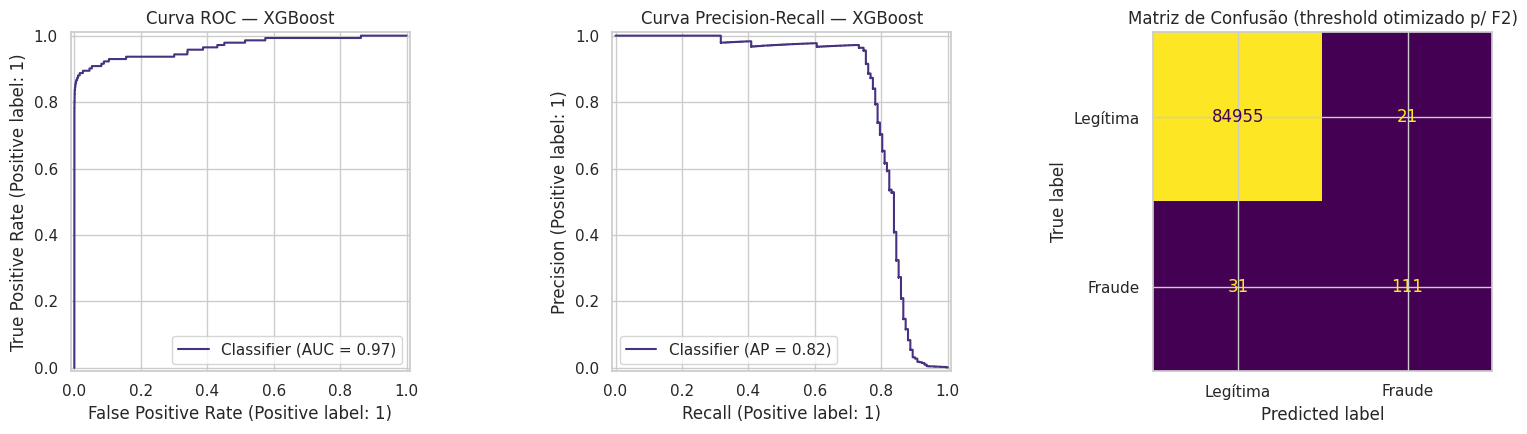

In [19]:
test_predictions = pd.read_parquet(ROOT / "outputs" / "test_predictions.parquet")

from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

RocCurveDisplay.from_predictions(
    test_predictions["Class_real"], test_predictions["proba_fraude_xgb"], ax=axes[0]
)
axes[0].set_title("Curva ROC — XGBoost")

PrecisionRecallDisplay.from_predictions(
    test_predictions["Class_real"], test_predictions["proba_fraude_xgb"], ax=axes[1]
)
axes[1].set_title("Curva Precision-Recall — XGBoost")

cm = confusion_matrix(
    test_predictions["Class_real"], test_predictions["pred_threshold_otimizado"]
)
ConfusionMatrixDisplay(cm, display_labels=["Legítima", "Fraude"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Matriz de Confusão (threshold otimizado p/ F2)")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "06_curvas_avaliacao.png")
plt.show()


## 8. Importância das variáveis (conectada ao domínio do problema)

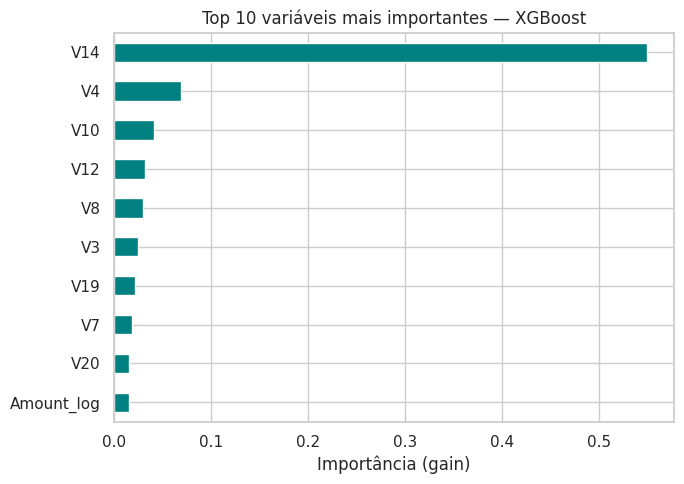

In [20]:
top_features = results["top_10_features_xgboost"]
feat_series = pd.Series(top_features).sort_values()

plt.figure(figsize=(7, 5))
feat_series.plot(kind="barh", color="teal")
plt.title("Top 10 variáveis mais importantes — XGBoost")
plt.xlabel("Importância (gain)")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "07_feature_importance.png")
plt.show()


**Interpretação conectada ao domínio:** a variável `V14` domina a
importância do modelo (~55% do total). Embora seja uma componente PCA
sem rótulo de negócio explícito, sua dominância é consistente com a
literatura pública sobre este dataset (é o padrão mais reportado em
análises deste mesmo conjunto de dados). Isso reforça que, mesmo com a
anonimização por PCA, o modelo consegue isolar um eixo latente que
concentra a maior parte do sinal discriminativo entre fraude e
transação legítima — provavelmente relacionado a combinações de
comportamento de gasto e canal de transação que a PCA comprimiu em uma
única componente.


## 9. Tradução para negócio: custo financeiro simulado

Para ir além das métricas técnicas, simulamos um custo financeiro por
modelo, usando parâmetros hipotéticos (documentados no README, já que o
briefing do stakeholder não informou valores reais):

- **Custo de um Falso Negativo** (fraude não detectada): R$ 500 (valor médio estimado de prejuízo por fraude não capturada)
- **Custo de um Falso Positivo** (cliente legítimo sinalizado): R$ 5 (custo operacional de revisão manual/atrito com cliente)

> `Custo total = FN × R$500 + FP × R$5`


In [21]:
cost_df = metrics_df[["model", "false_negative", "false_positive", "custo_financeiro_simulado_R$"]]
cost_df = cost_df.sort_values("custo_financeiro_simulado_R$")
cost_df


,model,false_negative,false_positive,custo_financeiro_simulado_R$
4,XGBoost (threshold otimizado p/ F2),31,21,15605.0
3,XGBoost (scale_pos_weight),34,12,17060.0
5,XGBoost + SMOTE,34,30,17150.0
2,Random Forest,36,14,18070.0
1,Regressão Logística,16,2349,19745.0
6,Isolation Forest (não-supervisionado),109,108,55040.0
0,Dummy (baseline),142,0,71000.0


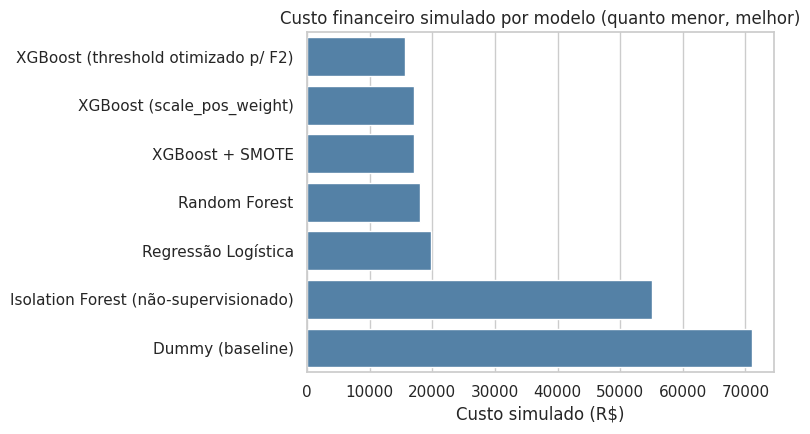

In [22]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=cost_df, y="model", x="custo_financeiro_simulado_R$", color="steelblue")
plt.title("Custo financeiro simulado por modelo (quanto menor, melhor)")
plt.xlabel("Custo simulado (R$)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "08_custo_financeiro.png")
plt.show()


**Insight de negócio:** sob esses parâmetros de custo, o **XGBoost com
threshold otimizado para F2** apresenta o menor custo simulado entre
todos os modelos testados — mesmo não sendo o de maior PR-AUC bruto.
Isso ilustra um ponto importante: **a melhor métrica técnica nem sempre
corresponde à melhor decisão de negócio** — o threshold de decisão
importa tanto quanto o modelo escolhido.


## 10. Recomendação final (Data Storytelling)

**Modelo recomendado:** XGBoost com `scale_pos_weight`, usando o
threshold de decisão otimizado (≈0,147 em vez do padrão 0,5) para
maximizar o F2-Score.

**Por quê:**
- Captura ~78% das fraudes no conjunto de teste, com apenas 21 falsos
  alarmes a cada ~85 mil transações analisadas — uma carga operacional
  administrável para o time de risco.
- Tem o menor custo financeiro simulado entre todos os modelos
  comparados.
- É consideravelmente mais rápido de treinar e explicar que uma
  combinação com SMOTE, e não depende de gerar dados sintéticos.

**Limitações a comunicar ao stakeholder:**
- As variáveis V1-V28 são componentes PCA anônimas — o modelo aponta
  *quais* dimensões latentes mais pesam na decisão (ex.: V14), mas não
  conseguimos traduzir isso para "categoria de compra" ou "canal", pois
  a base não disponibiliza esse mapeamento por questões de sigilo.
- O período de coleta é de apenas 2 dias — um re-treino periódico é
  necessário para capturar mudanças de padrão de fraude ao longo do
  tempo (concept drift).
- Os parâmetros de custo financeiro usados são hipotéticos; o ideal é
  substituí-los pelos valores reais do banco assim que disponíveis.

**Próximos passos sugeridos:**
1. Validar o threshold ótimo com o time de operações de risco (trade-off real entre recall e carga de revisão manual).
2. Monitorar drift do modelo em produção (distribuição das features e da taxa de fraude ao longo do tempo).
3. Considerar o Isolation Forest como camada complementar para capturar fraudes de padrão novo, ainda não vistas no treino supervisionado.
4. Avaliar a viabilidade de captura de features adicionais (categoria de merchant, geolocalização, dispositivo) para reduzir a dependência de componentes PCA anônimas.
